<div style="width:100%; text-align:center; padding:10px 0;">
<img src="project_header.png" style="width:100%; max-width:100vw; height:auto; display:block; margin:0 auto;">
</div>

# EO Africa SWAM project 
## Process and plot TSM for single Sentinel-2 L1C file

#### This notebook does the following:
* Use EODAG to search for a Sentinel-2 L1C file for a region of interest and date range (example provided for Theewaterskloof dam, South Africa)
* Apply the C2X-Complex atmospheric correction using a SNAP processing graph
* Apply the [Jiang et al (2023)](https://doi.org/10.1016/j.isprsjprs.2023.09.020) TSM algorithm
* Plot the output TSM product 

#### Requirements:
* This notebook was origninally written for application in the EO Africa Innovation Lab enviroment. It can be adapted for use on the [Copernicus Data Space Ecosystem](https://jupyterhub.dataspace.copernicus.eu/hub/login?next=%2Fhub%2F), [DUNIA Sandbox](https://dunia.esa.int/sandbox), or personal machine.
* This notebook requires an installation of [SNAP](https://step.esa.int/main/download/snap-download/), with the Idepix extension. 
* This notebook requires a SNAP graph processing framework file (example provided *resample_subset_idepix_c2xc_TW.xml*) in order to apply the atmospheric correction

#### Settings to adjust manually:
in code cell 1 :
* adjust the lake/dam name  (options: ZV, RV, TW, MV, VV, CW), default is TW.
* adjust the coordinates for a region of interest (default is for TW)
* ensure that the appropriate start and end dates are defined in format "yyyy-mm-dd"
* set up the path of the shapefile (EO_Africa_lake_polygon_updated.geojson), which will be used to mask out land pixels
* NOTE: if adjusting to different area, also edit the the polygon in line 25 of the xml file

in code cell 3:
* adjust the name of the gpt graph (if not using the default)
* adjust the path to the SNAP bin folder (if not working on Innovation lab or DUNIA sandbox)


### Version history:
* Version 1.0, 23 Feb, 2026


##### Authors:
**Dalin Jiang**, University of Stirling, UK;

**Marie Smith**, CSIR, South Africa

In [1]:
import os
import glob
import subprocess
import numpy as np
import rasterio
from eodag import EODataAccessGateway, setup_logging
import re
import sys
import time
import warnings
warnings.filterwarnings('ignore')
import numba
import geopandas as gpd
from datetime import datetime
from scipy.interpolate import griddata
import xarray as xr

## Step 1: Define the study area and time period
In this cell, the spatial coverage and the start and end dates of the processing need to be set up

The example of lake Theewaterskloof (TW) is used here below.

In [2]:
# 1.1. spatial coverage of the lake, coordinates are in decimal degree
lake_name = "TW"
latmin = -34.0982   
latmax = -33.9652  
lonmin = 19.0989
lonmax = 19.3181

# 1.2. start and end date in the format of 'YYYY-MM-DD'
start_date = "2023-10-16"
end_date = "2023-10-18"

# 1.3. lake shape file to crop the image and mask out land pixels
roi_file = "EO_Africa_lake_polygon_updated.geojson"

In [3]:
# geospatial range
wkt = f"POLYGON(({lonmin} {latmax}, {lonmin} {latmin}, {lonmax} {latmin}, {lonmax} {latmax}, {lonmin} {latmax}))" 

# read the roi file
roi = gpd.read_file(roi_file)

# the file path and name of the xml graph:
gpt_graph = "resample_subset_idepix_c2xc_"+lake_name+".xml"    
## the path to the "bin" folder in your snap installation:
snap_gpt = '/usr/local/snap/bin/gpt'

# set up output path
working_dir = os.getcwd()
output_path = os.path.join(working_dir,"outputs/")

## the path to the folder where completed files will be saved
if not os.path.exists(output_path):
    os.makedirs(output_path)
    print(f"Created folder: {output_path} \n")
else:
    print(f"Folder {output_path} already exists. \n") 
 

Folder /home/eoafrica/shared/SWAM/FINAL_CODE/outputs/ already exists. 



## Step 2: Search for filename

Now we will use the EODAG tool to search for all the filenames that intersect with our search area and time period within the *eodata* folder of the Jupyter Lab, and create a list of the precise file locations. You can either use **creodias** or **cop_dataspace** as the provider

In [4]:
setup_logging(1)  # 0: nothing, 1: only progress bars, 2: INFO, 3: DEBUG

dag = EODataAccessGateway()

search_results = dag.search(
    provider="creodias",
    productType="S2_MSI_L1C",
    geom=wkt,
    start=start_date,
    end=end_date,
)

input_file = '/home/eoafrica'+search_results[0].properties['productIdentifier']#+'/MTD_MSIL1C.xml'
#print(search_results)
print(f'Found image: {input_file}')
print('\n')

Found image: /home/eoafrica/eodata/Sentinel-2/MSI/L1C_N0500/2023/10/17/S2A_MSIL1C_20231017T081931_N0510_R121_T34HCH_20241101T172545.SAFE




## Step 3: Run pre-processing for the image
This include the following processing:
* resampling the image to 20 m spatial resolution
* spatial subset the image
* cloud identification
* atmospheric correction

In [5]:
# functions for image pre-processing
def pre_processing(in_image, lake_name, output_path):
    image_info = os.path.basename(in_image).split('_')   
    out_image = output_path+image_info[0]+'_'+image_info[2]+'_'+image_info[5]+'_C2XC_'+lake_name
    
    subprocess.run([
        snap_gpt,
        gpt_graph,
        '-SsourceProduct=',in_image,
        '-t',out_image,
        '-f','NetCDF4-BEAM'  #'NetCDF4-CF'
    ])

    return out_image


Below is the main processing step where you read the input file, run the file through the SNAP using the graph processing framework, and create a netcdf output. For a single file this step can take a few minutes to complete for a small lake, but it can take over 30 minutes to process a scene over a larger lake - so be patient!

In [6]:
# process the satellite image

start_time = time.time()  # Record the start time of the current iteration

dirpath = input_file #os.path.dirname(input_file)

print(f'Start to process >> {os.path.basename(input_file)}')
out_img = pre_processing(in_image=dirpath, 
               lake_name=lake_name, 
               output_path=output_path)

print('-------------------------------------------------------------')
print(f'Finish >> {os.path.basename(input_file)}')
elapsed_time = time.time() - start_time
print(f"Time used = {elapsed_time:.4f} seconds")

Start to process >> S2A_MSIL1C_20231017T081931_N0510_R121_T34HCH_20241101T172545.SAFE
Executing processing graph


32640 [main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
32640 [main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
32645 [main] INFO hdf.hdf5lib.H5 - HDF5 library: 
32645 [main] INFO hdf.hdf5lib.H5 -  successfully loaded.
/home/eoafrica/.snap/auxdata/gdal/gdal-3-7-2/lib/jni/../libstdc++.so.6: version `GLIBCXX_3.4.29' not found (required by /lib/x86_64-linux-gnu/libproxy.so.1)
Failed to load module: /usr/lib/x86_64-linux-gnu/gio/modules/libgiolibproxy.so


Initializing Elevation Model
100% done.

100% done.

100% done.

100% done.

100% done.

100% done.
11%22%33%45%56%67%.78%....88%

205959 [main] INFO serverStartup - Nc4Iosp: NetCDF-4 C library loaded (jna_path='/home/eoafrica/.snap/auxdata/netcdf_natives/12.0.1/amd64', libname='netcdf').
205962 [main] INFO serverStartup - NetcdfLoader: set log level: old=0 new=0
205963 [main] INFO serverStartup - Nc4Iosp: set log level: old=0 new=0


. done.
-------------------------------------------------------------
Finish >> S2A_MSIL1C_20231017T081931_N0510_R121_T34HCH_20241101T172545.SAFE
Time used = 618.9814 seconds


## Step 4: Calculate TSM concentration
TSM algorithm from Jiang et al. (2023) is used, with re-calibrated coefficients using in situ data

In [7]:
@numba.njit
def Estimate_TSS_Jiang(site_Rrs):
    """
    Estimate TSS using the method from Jiang et al., 2023, ISPRS
    inputs: one numpy array containing Rrs (units: sr-1) spectrum at 443, 490, 560, 665, 705, 740, 783, 865 nm 
    outputs: TSM, units: g/m3
    """
    aw = np.array([0.00515124,0.01919594,0.06299986,0.41395333,0.70385758,2.71167020,2.62000141,4.61714226])
    bbw = np.array([0.00215037,0.00138116,0.00078491,0.00037474,0.00029185,0.00023499,0.00018516,0.00012066])
    wave =  np.array([443.0,490.0,560.0,665.0,705.0,740.0,783.0,865.0])

    def QAA_560(site_Rrs):
        rrs = site_Rrs/(0.52+1.7*site_Rrs)
        u = (-0.089+np.sqrt((0.089**2)+4*0.125*rrs))/(2*0.125)
        x = np.log10((rrs[0]+rrs[1])/(rrs[2]+5*rrs[3]*rrs[3]/rrs[1]))
        a560 = aw[2]+10.0**(-1.146-1.366*x-0.469*(x**2))
        bbp560 = ((u[2]*a560)/(1-u[2]))-bbw[2]
        one_tss = 40.35141492*bbp560
        return(one_tss)

    def QAA_665(site_Rrs):
        rrs = site_Rrs/(0.52+1.7*site_Rrs)
        u = (-0.089+np.sqrt((0.089**2)+4*0.125*rrs))/(2*0.125)
        a665 = aw[3]+0.39*((site_Rrs[3]/(site_Rrs[0]+site_Rrs[1]))**1.14)
        bbp665 = ((u[3]*a665)/(1-u[3]))-bbw[3]
        one_tss = 43.9677864*bbp665
        return(one_tss)    

    def QAA_740(site_Rrs):
        rrs = site_Rrs/(0.52+1.7*site_Rrs)
        u = (-0.089+np.sqrt((0.089**2)+4*0.125*rrs))/(2*0.125)
        bbp740 = ((u[5]*aw[5])/(1-u[5]))-bbw[5]
        one_tss = 46.41238517*bbp740
        return(one_tss) 

    def QAA_865(site_Rrs):
        rrs = site_Rrs/(0.52+1.7*site_Rrs)
        u = (-0.089+np.sqrt((0.089**2)+4*0.125*rrs))/(2*0.125)
        bbp865 = ((u[7]*aw[7])/(1-u[7]))-bbw[7]
        one_tss = 50.15399306*bbp865
        return(one_tss) 

    def estimate_Rrs620(in665):
        a = 1.693846e+02                
        b = -1.557556e+01                 
        c = 1.316727e+00                  
        d = 1.484814e-04                
	
        est620 = a*in665**3 + b*in665**2 + c*in665 + d	
        return(est620)

    Rrs620 = estimate_Rrs620(site_Rrs[3])

    if (np.all((np.isnan(site_Rrs)) | (site_Rrs == 0))):
        tmp_tss = np.nan
    elif (site_Rrs[1] > site_Rrs[2]):
        tmp_tss = QAA_560(site_Rrs)
    elif (site_Rrs[1] > Rrs620):
        tmp_tss = QAA_665(site_Rrs)    
    elif ((site_Rrs[5] > site_Rrs[1]) & (site_Rrs[5] > 0.010)):
        tmp_tss = QAA_865(site_Rrs)      
    else:
        tmp_tss = QAA_740(site_Rrs)

    return(tmp_tss)


def convert_curvilinear_to_grid(ds, var_name):
    """
    convert curvilinar data to regular grid data for Sentinel-2 MSI
    inputs: (1)ds: DataSet (2) var_name: the name of variable in ds to be converted
    outputs: grid data in WGS84 containing the variable been converted
    """
    # Flatten curvilinear coordinates and data
    one_var = ds[var_name]
    geo_pts = np.column_stack([ds.lon.values.ravel(), ds.lat.values.ravel()])
    var_dt = one_var.values.ravel() 

    # define the size of output file
    xsize = one_var.shape[1]  # width, lon
    ysize = one_var.shape[0]  # height, lat

    # define pixel size of output
    #pixel_size = 0.00018  # apprximate 20 m
    
    # Define target grid
    lon_new, lat_new = np.meshgrid(
        np.linspace(ds.lon.min(), ds.lon.max(), xsize),
        np.linspace(ds.lat.min(), ds.lat.max(), ysize)
    )
    # Interpolate (linear/cubic/nearest)
    regridded_dt = griddata(
        geo_pts, var_dt,
        (lon_new, lat_new),
        method='linear'
    )
    
    # Create new xarray Dataset
    ds_new = xr.Dataset(
        {var_name: (('y', 'x'), regridded_dt)}, # y=lat, x=lon
        coords={
            'y': lat_new[:,0],
            'x': lon_new[0,:]
        }
    )
    
    return(ds_new)


def crop_lake_and_add_info(ds, lake_shape, lake_name):
    """
    ds: the raw image to be cropped
    lake_shape: the shape file containing all study lakes
    lake_name: short name of the lake, to get a single lake shape from the shape file, i.e., ZV, TW, RV
    """
    ds = ds.rio.write_crs("EPSG: 4326")
    lake_roi = lake_shape[lake_shape["Short_name"] == lake_name]
    mk_arr = ds["TSM"].rio.clip(lake_roi.geometry.values, drop=True)
    mk_dt = mk_arr.to_dataset(name="TSM")

    # convert data to float32 to save space
    for var in ['x','y','TSM']:
        mk_dt[var] = mk_dt[var].astype('float32')

    # change coordinates name, otherwise SNAP won't read correctly
    mk_dt = mk_dt.rename({'y':'lat', 'x':'lon'})
    
    # add attributes
    mk_dt["TSM"].attrs={'standard_name':'Total Suspended Matter',
                        'short_name':'TSM',
                       'units': 'g m^-3',
                       'grid_mapping':'spatial_ref'}

    # add global attributes
    mk_dt.attrs = {'Product': 'Total Suspended Matter',
                   'Units': 'g m^-3',
                   'Sensor': 'Sentinel2-MSI',
                   'AC Algorithm': 'C2XComplex',
                   'AC Algorithm DOI': 'Brockmann et al. (2016)',
                   'TSM algorithm': 'Jiang et al. (2023)',
                   'TSM algorithm DOI': 'https://doi.org/10.1016/j.isprsjprs.2023.09.020',
                   'Project': 'ESA EO Africa R&D SWAM',
                   'Project PI':'Marie Smith, CSIR; Dalin Jiang, University of Stirling',
                   'PI contact':'msmith2@csir.co.za; dalin.jiang@stir.ac.uk'
                   }
    
    return(mk_dt)


def mask_cloud_risk(ds, wq_dt):
    """
    To mask out pixels with cloud risk
    input: (1)ds: Rrs DataSet from C2XComplex; (2) wq_dt: water quality DataArray, i.e., Chla, TSM
    output: cloud_risk masked water quality data
    
    """
    # Access flags and chlorophyll as Dask arrays (do NOT call .values)
    flags = ds['c2rcc_flags']
    
    # Define which flag bits to mask out
    mask_flags = [8]
    
    # Create bitwise mask using Dask array operations (lazy)
    cloud_mask = np.zeros(flags.shape, dtype=bool)
    for f in mask_flags:
        cloud_mask = cloud_mask | (flags & f != 0)
    
    # Invert to get valid pixels mask
    valid_mask = ~cloud_mask

    # Create mask for chlorophyll > 0 (lazy operation)
    data_mask = wq_dt > 0

    # Combine masks
    combined_mask = data_mask & valid_mask

    # Use combined_mask to mask chlorophyll (this remains lazy)
    masked_wq = wq_dt.where(combined_mask)

    return (masked_wq)

In [ ]:
# open the atmospheric corrected image
#out_img = '/home/eoafrica/shared/SWAM/FINAL_CODE/outputs/S2A_20150810T084916_T34HCH_C2XC_TW.nc'
out_img = out_img+'.nc'
one_dt = xr.open_dataset(out_img)        #,chunks={"x": 512, "y": 512}
one_rrs = one_dt[['rrs_B1','rrs_B2','rrs_B3','rrs_B4','rrs_B5','rrs_B6','rrs_B7','rrs_B8A']].chunk({"x": 1000, "y": 1000})

# get image information: name of lake, date and time
img_info = os.path.basename(out_img)
lake_name = img_info.split('_')[4].replace('.nc','')
time_stamp = datetime.strptime(img_info.split('_')[1], "%Y%m%dT%H%M%S") 

# convert to 3D array: band, x, y
grd_dt = one_rrs.to_array(dim='band')
grd_dt = grd_dt.chunk(dict(x=1000, y=1000, band=-1)) #band: -1 means all bands in one chunk — important for apply_ufunc.

# prepare dask for running the calculation
result = xr.apply_ufunc(
    Estimate_TSS_Jiang,
    grd_dt,  # 3D DataArray with dims ('band', 'y', 'x')
    input_core_dims=[["band"]], # along with dim to apply the function
    #output_core_dims=[],
    vectorize=True,
    dask="parallelized",    # use only if `da` is dask-backed
    output_dtypes=[float]
)
# trigger the computing
raw_result = result.compute()
raw_dt = mask_cloud_risk(ds=one_dt, wq_dt=raw_result).to_dataset(name="TSM")   # mask cloud risk and convert to dataset  

# convert the data to a regular grid 
reg_dt = convert_curvilinear_to_grid(ds=raw_dt, var_name='TSM')
water_dt = crop_lake_and_add_info(ds=reg_dt, lake_shape=roi, lake_name=lake_name)
water_dt = water_dt.expand_dims(dim={'time':[time_stamp]})
water_dt.attrs["start_date"] = one_dt.attrs["start_date"]  # copy information
water_dt.attrs["stop_date"] = one_dt.attrs["stop_date"]

comp = dict(zlib=True, complevel=6, dtype='float32')  # 1–9 (higher = more compression, slower)
encoding = {var: comp for var in water_dt.data_vars}

out_file = os.path.join(output_path, img_info.replace(".nc","_TSM.nc"))
water_dt.to_netcdf(out_file,format='NETCDF4', encoding=encoding)
print('------------------------------------------------------------------')
print(f'Finished TSM estimation, results are exported to: {out_file} \n')

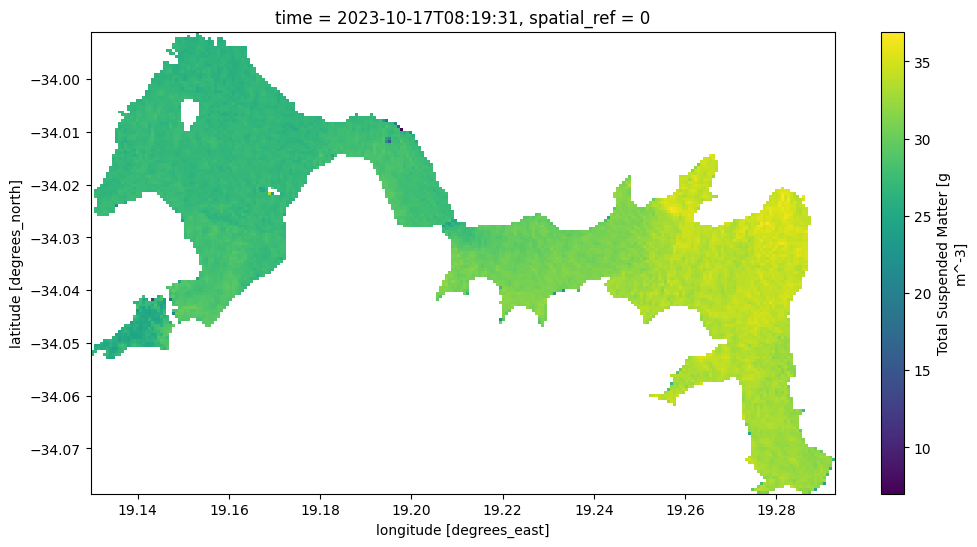

In [10]:
# plot the TSM rsults

water_dt.TSM.plot(aspect=2, size=6)